In [1]:
from google.colab import files

print("Upload your files:")
uploaded = files.upload()

Upload your files:


Saving y_true_binary.npy to y_true_binary.npy
Saving spatial_features_test.npy to spatial_features_test.npy
Saving spatial_features_train.npy to spatial_features_train.npy


In [2]:
import numpy as np

features_train = np.load('spatial_features_train.npy')
features_test = np.load('spatial_features_test.npy')
y_true_binary = np.load('y_true_binary.npy')

print("=== Data Loaded Successfully ===")
print(f"features_train shape : {features_train.shape}")
print(f"features_test shape  : {features_test.shape}")
print(f"y_true_binary shape  : {y_true_binary.shape}")
print(f"\nLabel Distribution:")
print(f"  Normal (0):  {np.sum(y_true_binary == 0)}")
print(f"  Anomaly (1): {np.sum(y_true_binary == 1)}")

=== Data Loaded Successfully ===
features_train shape : (3615, 128)
features_test shape  : (5149, 128)
y_true_binary shape  : (5122,)

Label Distribution:
  Normal (0):  2496
  Anomaly (1): 2626


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Use only clean (weapon-free) training frames
# features_train already contains only normal frames
feature_dim = 128

# Build Dense Autoencoder (single frame, no temporal context)
inputs = Input(shape=(feature_dim,), name="Frame_Input")

# ENCODER
x = Dense(64, activation='relu', name="Encoder_1")(inputs)
encoded = Dense(32, activation='relu', name="Bottleneck")(x)

# DECODER
x = Dense(64, activation='relu', name="Decoder_1")(encoded)
outputs = Dense(feature_dim, activation='linear', name="Reconstruction")(x)

dense_autoencoder = Model(inputs, outputs, name="Dense_Autoencoder")
dense_autoencoder.compile(optimizer='adam', loss='mse')
dense_autoencoder.summary()

# Training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining Dense Autoencoder on clean frames...")
history = dense_autoencoder.fit(
    features_train, features_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Model: "Dense_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Frame_Input (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_1 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_1 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reconstruction (Dense)          │ (None, 128)            │         8,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,768 (81.12 KB)

 Trainable params: 20,768 (81.12 KB)

 Non-trainable params: 0 (0.00 B)


Training Dense Autoencoder on clean frames...
Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 8.6328e-04 - val_loss: 4.3221e-05
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.8771e-06 - val_loss: 9.5160e-06
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3603e-07 - val_loss: 8.8645e-06
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9891e-08 - val_loss: 8.8704e-06
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9629e-08 - val_loss: 8.9496e-06
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9701e-08 - val_loss: 8.8837e-06
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9554e-08 - val_loss: 8.9205e-06
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9663e-08 - val_loss: 8.8440e-06
Epoch 9/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9865e-08 - val_loss: 8.8501e-06
Epoch 10/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9988e-08 - val_loss: 8.9589e-06
Epoch 11/50
46/46 ━━━━━━━━━━━━━

In [4]:
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# 1. Get per-frame reconstruction error on ALL test frames
test_reconstructions = dense_autoencoder.predict(features_test, verbose=0)
frame_mse = np.mean(np.square(features_test - test_reconstructions), axis=1)
print(f"Per-frame MSE shape: {frame_mse.shape}")  # should be (5149,)

# 2. Aggregate into 10-frame windows (same logic as spatial pipeline)
# Must respect camera boundaries
camera_limits_test = [3511, 607, 1031]  # same as before
sequence_length = 10

sequence_scores = []
start_idx = 0

for limit in camera_limits_test:
    end_idx = start_idx + limit
    camera_block = frame_mse[start_idx:end_idx]

    for i in range(0, len(camera_block) - sequence_length + 1):
        window = camera_block[i:i + sequence_length]
        sequence_scores.append(np.mean(window))  # average MSE over 10 frames

    start_idx = end_idx

sequence_scores = np.array(sequence_scores)
print(f"Sequence scores shape: {sequence_scores.shape}")  # should be (5122,)

# 3. Calibrate using validation frames
val_size = int(len(features_train) * 0.2)
val_features = features_train[-val_size:]
val_reconstructions = dense_autoencoder.predict(val_features, verbose=0)
val_mse = np.mean(np.square(val_features - val_reconstructions), axis=1)
mean_val_mse = np.mean(val_mse)

print(f"\nValidation MSE Mean: {mean_val_mse:.8f}")

# 4. Compute anomaly scores
test_anomaly_scores = np.abs(sequence_scores - mean_val_mse)
inverted_scores = -test_anomaly_scores

# 5. ROC AUC
roc_auc = roc_auc_score(y_true_binary, inverted_scores)
print(f"Dense Autoencoder ROC AUC: {roc_auc:.4f}")

# 6. Optimal threshold via Youden's J
fpr, tpr, thresholds = roc_curve(y_true_binary, inverted_scores)
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

y_pred = (inverted_scores > optimal_threshold).astype(int)

print(f"Optimal Threshold: {optimal_threshold:.6e}")
print("\nClassification Report:")
print(classification_report(
    y_true_binary, y_pred,
    target_names=["Normal (0)", "Anomaly (1)"],
    zero_division=0
))

Per-frame MSE shape: (5149,)
Sequence scores shape: (5122,)

Validation MSE Mean: 0.00000884
Dense Autoencoder ROC AUC: 0.9211
Optimal Threshold: -8.804062e-06

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.84      0.83      0.84      2496
 Anomaly (1)       0.84      0.85      0.85      2626

    accuracy                           0.84      5122
   macro avg       0.84      0.84      0.84      5122
weighted avg       0.84      0.84      0.84      5122



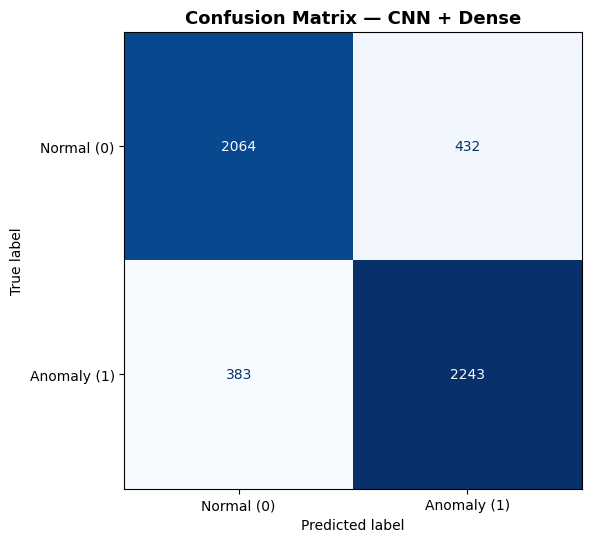

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_binary, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal (0)", "Anomaly (1)"]
)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d', colorbar=False)

plt.title("Confusion Matrix — CNN + Dense", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix_lstm_attention.png", dpi=150, bbox_inches='tight')
plt.show()